In [1]:
import numpy as np
# import essentia
# import essentia.standard as es
from scipy.signal import hilbert
import utils as u
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import torch
from torch.utils.data import DataLoader, Dataset
import sys, os
import torch
if os.path.abspath('.') not in sys.path:
    sys.path.append(os.path.abspath('.'))
import loss

SR = 44100

In [2]:
# Diff-SSL-G-Comp
SSL_DSET_PATH = "/Volumes/Saola's Drive/thesis/data/Diff-SSL-G-Comp"
DRY_PATH = '/processed_normalized'
WET_PATH = '/processed_ground_truth'
path_dry = SSL_DSET_PATH+DRY_PATH+'/NosPalpitants_UnmasteredWAV.wav'
path_wet = SSL_DSET_PATH+WET_PATH+'/threshold_-12_attack_10_release_0.4_ratio_10/NosPalpitants-exported.wav'
t, sig_dry = u.load_audio(path_dry)
t, sig_wet = u.load_audio(path_wet)

In [2]:
# LA2A
path_dry = "/Volumes/Saola's Drive/thesis/data/LA2A/all/input_158_.wav"
path_wet = "/Volumes/Saola's Drive/thesis/data/LA2A/all/target_158_LA2A_3c__0__100.wav"
t, sig_dry = u.load_audio(path_dry)
t, sig_wet = u.load_audio(path_wet)

In [ ]:
# CL1B
CL1B_TEST_PATH = "/Volumes/Saola's Drive/thesis/data/CL1B/data_test.pickle"
def load_cl1b_test(path: str | Path = CL1B_TEST_PATH):
    path = Path(path)
    with path.open("rb") as f:
        data = pickle.load(f)
    return data

cl1b_data = load_cl1b_test()

sig_dry = cl1b_data['inp'][0]
sig_wet = cl1b_data['tar'][0]
t = np.arange(len(sig_dry))/SR

# Calc signals

In [3]:
gr_eval = {}
output_eval = {}

# normalisation
max_peak = max(np.max(sig_dry), np.max(sig_wet))
sig_dry = sig_dry/max_peak
sig_wet = sig_wet/max_peak

# difference
diff = np.divide(sig_wet, sig_dry, out=np.ones_like(sig_wet), where=(sig_dry != 0))
gr_diff = np.abs(diff)
diff_dB = u.to_dB(gr_diff)
# Now this will be completely safe and warning-free
recreated_sig_diff = sig_dry * diff
gr_eval['Difference'] = diff_dB
output_eval['Difference'] = recreated_sig_diff

# Hilbert
analytic_signal_dry = hilbert(sig_dry)
env_dry = np.abs(analytic_signal_dry)

analytic_signal_wet = hilbert(sig_wet)
env_wet = np.abs(analytic_signal_wet)

gr_hilbert = env_wet / env_dry
gr_dB_hilbert = u.to_dB(gr_hilbert)
recreated_sig_hilbert = sig_dry * gr_hilbert

gr_eval['Hilbert env'] = gr_dB_hilbert
output_eval['Hilbert env'] = recreated_sig_hilbert

# Calculate RMS models for the different window sizes
eval_windows = [64, 4096]
for win_size in eval_windows:
    gr_eval[f"RMS {win_size}"] = u.calc_gain_reduction(sig_dry, sig_wet, window_size=win_size)
    output_eval[f"RMS {win_size}"] = sig_dry * u.to_amplitude(gr_eval[f"RMS {win_size}"])


avg_gr_db = np.mean(gr_eval["RMS 4096"])
avg_gr = u.to_amplitude(avg_gr_db)
recreated_avg = sig_dry * avg_gr
gr_eval[f"Mean RMS {np.round(avg_gr_db,2)}dB"] = avg_gr
output_eval[f"Mean RMS {np.round(avg_gr_db,2)}dB"] = recreated_avg

output_eval['Input'] = sig_dry


# PLOTS

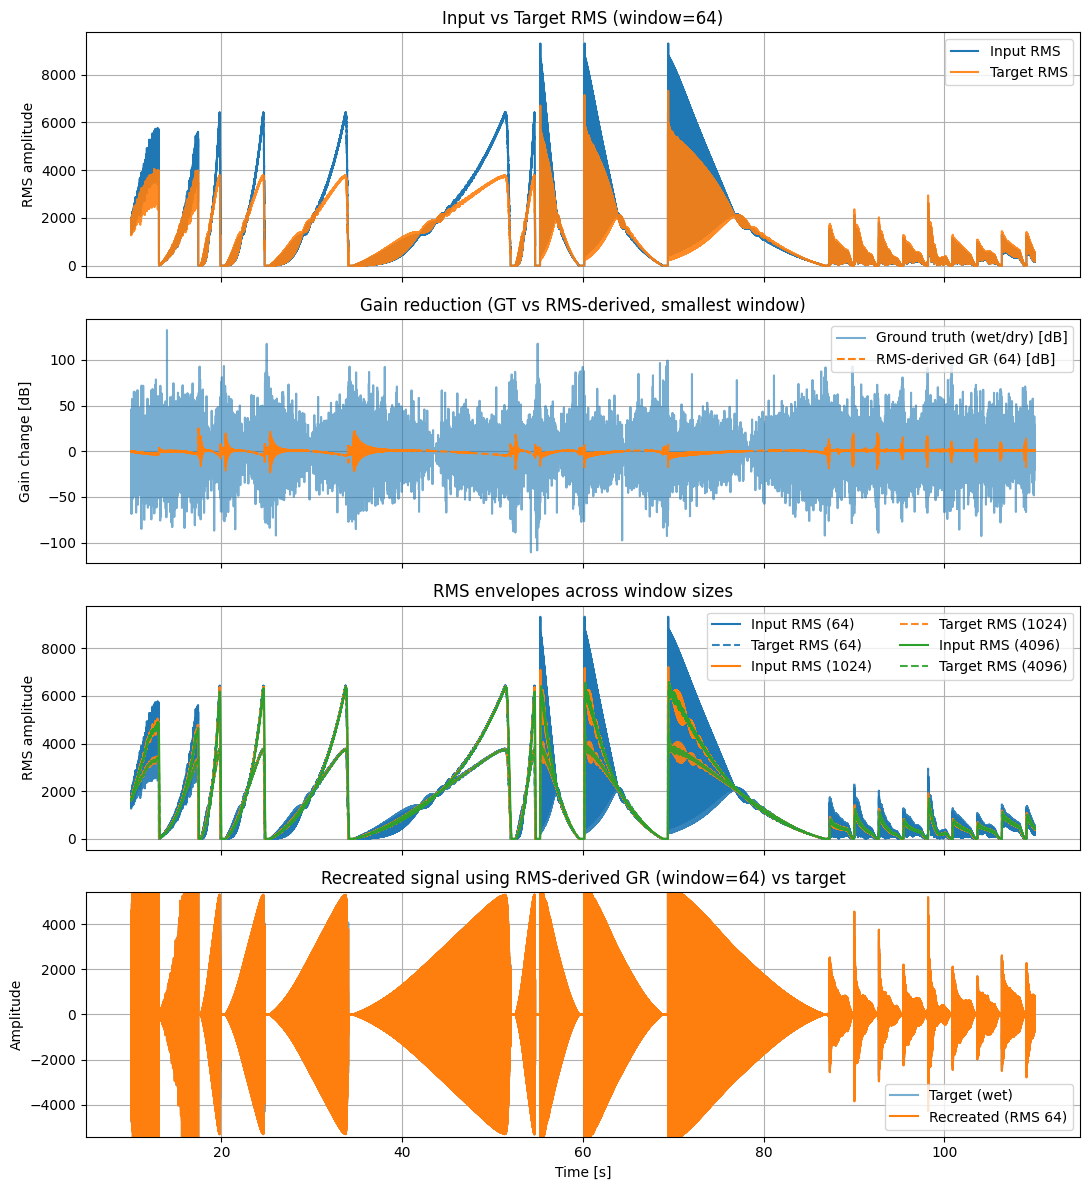

In [ ]:
# PLOTTING

t_start = 10
t_length = 100

# restrict all signals to the plotted time window
mask = (t >= t_start) & (t <= t_start + t_length)

t_cut = t[mask]
sig_dry_cut = sig_dry[mask]
sig_wet_cut = sig_wet[mask]

a_win = int(min(eval_windows))

# 1) input vs target RMS (smallest window)
rms_in_small = u.window_rms(sig_dry, a_win, in_dB=False)
rms_tar_small = u.window_rms(sig_wet, a_win, in_dB=False)
rms_in_small_cut = rms_in_small[mask]
rms_tar_small_cut = rms_tar_small[mask]

# 2) RMS-derived gain reduction (from RMS envelopes)
eps = 1e-12
gr_rms_small_dB = 20 * np.log10((rms_tar_small + eps) / (rms_in_small + eps))
gr_rms_small_dB_cut = gr_rms_small_dB[mask]

# ground-truth gain change (wet/dry)
diff_dB_cut = diff_dB[mask]

# 4) recreate signal using smallest RMS-derived GR
recreated_sig_rms_small = sig_dry * u.to_amplitude(gr_rms_small_dB)
recreated_sig_rms_small_cut = recreated_sig_rms_small[mask]

fig, ax = plt.subplots(nrows=4, sharex=True, tight_layout=True, figsize=(11, 12))

# Plot 1: input vs target RMS (small)
ax[0].set_title(f"Input vs Target RMS (window={a_win})")
ax[0].set_ylabel("RMS amplitude")
ax[0].plot(t_cut, rms_in_small_cut, label="Input RMS")
ax[0].plot(t_cut, rms_tar_small_cut, label="Target RMS", alpha=0.9)
ax[0].grid()
ax[0].legend()

# Plot 2: gain reduction curves (GT vs RMS-derived GR)
ax[1].set_title("Gain reduction (GT vs RMS-derived, smallest window)")
ax[1].set_ylabel("Gain change [dB]")
ax[1].plot(t_cut, diff_dB_cut, label="Ground truth (wet/dry) [dB]", alpha=0.6)
ax[1].plot(t_cut, gr_rms_small_dB_cut, label=f"RMS-derived GR ({a_win}) [dB]", linestyle="--")
ax[1].grid()
ax[1].legend()

# Plot 3: compare RMS envelopes across window sizes (input + target)
ax[2].set_title("RMS envelopes across window sizes")
ax[2].set_ylabel("RMS amplitude")
for win in sorted(eval_windows):
    r_in = u.window_rms(sig_dry, int(win), in_dB=False)[mask]
    r_tar = u.window_rms(sig_wet, int(win), in_dB=False)[mask]
    (ln,) = ax[2].plot(t_cut, r_in, label=f"Input RMS ({int(win)})")
    ax[2].plot(t_cut, r_tar, label=f"Target RMS ({int(win)})", linestyle="--", color=ln.get_color(), alpha=0.9)
ax[2].grid()
ax[2].legend(ncol=2)

# Plot 4: recreated signal (smallest RMS) vs target
ax[3].set_title(f"Recreated signal using RMS-derived GR (window={a_win}) vs target")
ax[3].set_ylabel("Amplitude")
ax[3].set_xlabel("Time [s]")
ax[3].plot(t_cut, sig_wet_cut, label="Target (wet)", alpha=0.6)
ax[3].plot(t_cut, recreated_sig_rms_small_cut, label=f"Recreated (RMS {a_win})")
ax[3].grid()
ax[3].legend()

# zoom only here (peaks)
peak_sig = np.quantile(np.abs(np.concatenate([sig_wet_cut, recreated_sig_rms_small_cut])), 0.995)
ax[3].set_ylim(-peak_sig, peak_sig)

plt.show()


# Loss Calculations

In [4]:
name = "LA2A-norm"
df = loss.evaluate_to_dataframe(sig_wet, output_eval, loss, name, print_results=True)



LA2A-norm                   MSE         MAE         ESR        RMSE         SFE     M-STFTE
────────────────────────────────────────────────────────────────────────────────────────────
Difference             0.000000    0.000003    0.000029    0.000112    0.000490    0.003488
Hilbert env            0.000156    0.004412    0.362780    0.013815    0.021047    0.196843
RMS 64                 0.000126    0.003906    0.292667    0.011264    0.019627    0.187501
RMS 4096               0.000173    0.006015    0.403665    0.017033    0.022262    0.272302
Mean RMS -10.82dB      0.000564    0.012969    1.313394    0.031380    0.043905    0.738448
Input                  0.011462    0.061860   26.673838    0.120132    0.213281    4.102992


In [ ]:
df.to_excel(f"{name}_evaluation_results.xlsx", index=False)

In [4]:
from loss_evals import calc_losses
results = calc_losses(
    unmastered=path_dry,
    target=path_wet,
    model="TCN_S_TF",
    device="cpu"
)

Extracted params from target path: {'threshold': -12, 'attack': 10, 'release': 0.4, 'ratio': 10}
Params: threshold=-12, attack=10, release=0.4, ratio=10
Normalized: [0.20000000298023224, 0.3333333432674408, 0.25, 1.0]
Loading model: TCN_S_TF
  System class: BlackBoxSystem
  Cond type:    tfilm
  Checkpoint:   /Users/domonkos/Virtual-Analogue-Compressor-Modelling/nablafx-for-diffssl-compressor/experiments/TCN_S_TF/dafx/48c4642a/checkpoints/last.ckpt
Receptive Field:  2047


Comparison                        MAE (L1)    MSE (L2)         ESR     MR-STFT         EDC     M_NRMSE        M_SF
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TCN_S_TF Output → Target          0.002676    0.000013    0.225681    0.421771    1.660231    0.475058    0.008011
TCN_S_TF Output → Input           0.027578    0.001467    0.719944    2.385083    9.841583    0.848495    0.196712
Input → Target                    0.026969    0.001449   25.34